# Problem 1

Rederive the nondimensional equations (1a, 1b) in box 1 by starting with the dimensional biochemical rate equation formulation of gene expression for proteins $u, v$:

$\frac{dP_u}{dt} = \frac{X_u K_{m,v}^{\beta}}{K_{m,v}^{\beta} + P_v^{\beta}}-(\mu + k_{d,2})P_u$

$\frac{dP_v}{dt} = \frac{X_v K_{m,u}^{\gamma}}{K_{m,u}^{\gamma} + P_u^{\gamma}} - (\mu + k_{d,2})P_v$


| Variable             | Physical Meaning                                      | Dimension              |
|----------------------|--------------------------------------------------------|------------------------|
| $P_u, P_v$           | Protein concentration for u, v                        | Mass/Vol.              |
| $t$                  | Time                                                  | Time                   |
| $X_u, X_v$           | Maximum gene expression rate                          | Mass/Vol./Time         |
| $K_{m,v}; K_{m,u}$   | Protein concentration for half-maximal repression     | Mass/Vol.              |
| $\beta, \gamma$      | Hill coefficient                                      | Dimensionless          |
| $\mu$                | Growth rate                                           | $\text{Time}^{-1}$     |
| $k_{d,2}$            | Protein degradation rate                              | $\text{Time}^{-1}$     |


Define:

$ u = \frac{P_u}{K_{m,u}}, \quad v = \frac{P_v}{K_{m,v}}, \quad \tau = (\mu + k_{d,2})t$

$ \implies P_u = K_{m,u} u, \quad P_v = K_{m,v} v, \quad t = \frac{\tau}{\mu + k_{d,2}}$

Substitute $P_u, \text{ and } P_v$

$\implies K_{m,u} \frac{du}{dt} = \frac{X_u K_{m,v}^{\beta}}{K_{m,v}^{\beta} + (K_{m,v}v)^{\beta}}-(\mu + k_{d,2})K_{m,u}u$

$\implies K_{m,u} \frac{du}{dt} = \frac{X_u }{ 1 +  v^{\beta}} - ( \mu + k_{d,2} ) K_{m,u} u$

$ \implies  \frac{du}{dt} = \frac{X_u}{ K_{m,u}(1 +  v^{\beta})} - ( \mu + k_{d,2} ) u$

Convert $t \text{ to } \tau$: 

$\implies (u + k_{d,2})\frac{du}{d\tau} = \frac{X_u}{ K_{m,u}(1 +  v^{\beta})} - ( \mu + k_{d,2} ) u$

$ \implies \frac{du}{d\tau} = \frac{X_u}{ K_{m,u}(1 +  v^{\beta})} \cdot (u + k_{d,2})^{-1} - u$

allow for, $ \alpha_1 = \frac{X_u}{K_{m,u}(\mu + k_{d,2})}$

$\therefore \boxed{\frac{du}{d\tau} = \frac{\alpha_1}{1 + v^{\beta}} - u}$

Additionally, substituting $P_u, \text{ and } P_v$

$\implies K_{m,v}\frac{dv}{dt} = \frac{X_v K_{m,u}^{\gamma}}{K_{m,u}^{\gamma} + (K_{m,u} u )^{\gamma}} - (\mu + k_{d,2})K_{m,v}v$

$\implies K_{m,v} \frac{dv}{dt} = \frac{X_v}{1+u^{\gamma}} - (\mu + k_{d,2})K_{m,v}v$

$\implies \frac{dv}{dt} = \frac{X_v}{K_{m,v} ( 1 + u^{\gamma})} - (\mu + k_{d,2})v$

Convert $ t \text{ to } \tau$

$ \implies (u + k_{d,2})\frac{dv}{d\tau} = \frac{X_v}{K_{m,v} ( 1 + u^{\gamma})} - (\mu + k_{d,2})v$

allow for $\alpha_2 = \frac{X_v}{K_{m,v}(\mu + k_{d,2})}$

$ \therefore \boxed{\frac{dv}{d\tau} = \frac{\alpha_2}{( 1 + u^{\gamma})} - v}$

# Problem 2

In this section let’s analyze the system behavior when $\beta=2, \quad \gamma= 2$

## Problem 2a.	
Plot the nullclines for $\alpha_1 = 40, \quad \alpha_2 = 20$. Plot v on the y axis and u on the x axis. Note the steady state solution(s) on the graph and label which are stationary points (stable steady states). 


/var/folders/f2/lbj2f9h979b75rj33ps9wq780000gn/T/ipykernel_47608/2288851770.py:20: RuntimeWarning: invalid value encountered in sqrt
  nc1_v = np.where(inner > 0, inner ** (1 / beta), np.nan)


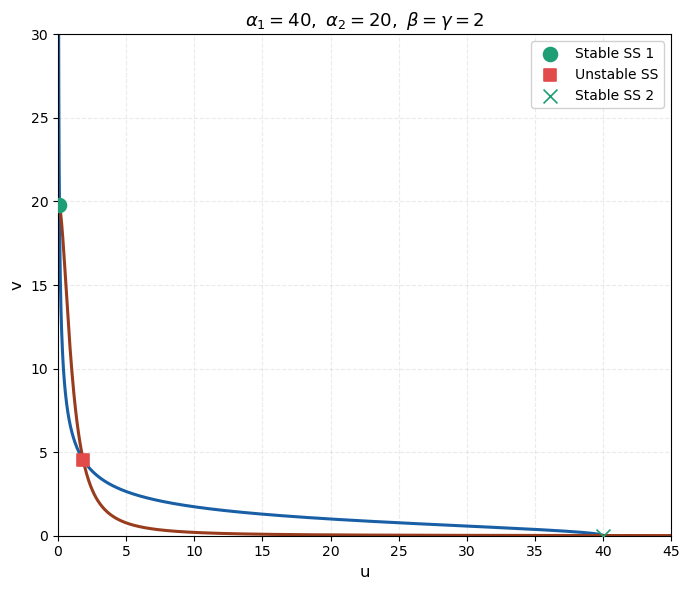

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Parameters
alpha1 = 40
alpha2 = 20
beta   = 2
gamma  = 2

# --- Nullcline functions ---
# du/dtau = 0  =>  alpha1 / (1 + v^beta) = u  =>  v = (alpha1/u - 1)^(1/beta)
# dv/dtau = 0  =>  alpha2 / (1 + u^gamma) = v

u = np.linspace(0.01, alpha1 * 1.15, 2000)

# du/dtau = 0 nullcline: v as a function of u
# valid only where alpha1/u - 1 > 0, i.e. u < alpha1
inner = alpha1 / u - 1
nc1_v = np.where(inner > 0, inner ** (1 / beta), np.nan)

# dv/dtau = 0 nullcline: v as a function of u
nc2_v = alpha2 / (1 + u ** gamma)

def f(u_val):
    v_val = alpha2 / (1 + u_val ** gamma)
    return alpha1 / (1 + v_val ** beta) - u_val

# Scan for sign changes to bracket roots
u_scan = np.linspace(0.01, alpha1 * 1.1, 10000)
f_scan = np.array([f(ui) for ui in u_scan])

roots_u, roots_v = [], []
for i in range(len(u_scan) - 1):
    if f_scan[i] * f_scan[i + 1] < 0:
        u_root = brentq(f, u_scan[i], u_scan[i + 1], xtol=1e-10)
        v_root = alpha2 / (1 + u_root ** gamma)
        roots_u.append(u_root)
        roots_v.append(v_root)

# Classify steady states (stable = outer, unstable = middle)
n_ss = len(roots_u)

labels    = ['Stable SS 1', 'Unstable SS', 'Stable SS 2']
markers   = ['o', 's', 'x']
colors_ss = ['#1D9E75', '#E24B4A', '#1D9E75']
sizes     = [100, 80, 100]

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(u, nc1_v, color='#185FA5', linewidth=2.2)
ax.plot(u, nc2_v, color='#993C1D', linewidth=2.2)

for i in range(n_ss):
    ax.scatter(roots_u[i], roots_v[i],
               s=sizes[i], color=colors_ss[i], marker=markers[i],
               zorder=5, linewidths=1.2,
               label=f'{labels[i]}')

ax.set_xlim(0, 45)
ax.set_ylim(0, 30)
ax.set_xlabel('u', fontsize=12)
ax.set_ylabel('v', fontsize=12)
ax.set_title(r'$\alpha_1=40,\ \alpha_2=20,\ \beta=\gamma=2$', fontsize=13)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

## Problem 2b.

Figure 2c shows the monostable and bistable regimes for this system. We don’t quite learn the mathematical tools to solve for this stability phase space. Instead, solve for the monostable phase boundarie(s) when $\alpha_1 = 40$. In other words, solve for the $\alpha_2$ value(s) at the boundary between monostability and bistability. Repeat this same analysis for $\alpha_1 = 80$ and show that your results have the same slope(s) as noted in Figure 2C.  Hint: you can plot the nullclines of varying $\alpha_2$ parameter values to identify which parameter values give you multiple steady states. 


In [ ]:
import numpy as np
from scipy.optimize import brentq
from IPython.display import display, Math

beta = gamma = 2

# At a saddle-node bifurcation, the nullclines are tangent:
# (1)  alpha1 / (1 + v^beta) = u          [du/dtau = 0]
# (2)  alpha2 / (1 + u^gamma) = v         [dv/dtau = 0]
# (3)  dv/du must be equal on both nullclines (tangency condition)
#
# From (1): v = (alpha1/u - 1)^(1/beta)
# From (2): v = alpha2 / (1 + u^gamma)
#
# Slope of nullcline 1 (dv/du):
#   v = (alpha1/u - 1)^(1/beta)
#   dv/du = (1/beta) * (alpha1/u - 1)^(1/beta - 1) * (-alpha1/u^2)
#
# Slope of nullcline 2 (dv/du):
#   v = alpha2 / (1 + u^gamma)
#   dv/du = -alpha2 * gamma * u^(gamma-1) / (1 + u^gamma)^2

def saddle_node_residuals(u_val, alpha1):
    """
    Given u, find alpha2 such that both nullclines pass through the
    same point AND have equal slopes (tangency = saddle-node bifurcation).
    Returns residual; root gives the bifurcation u-value.
    """
    if u_val <= 0 or u_val >= alpha1:
        return np.nan

    inner = alpha1 / u_val - 1
    if inner <= 0:
        return np.nan

    v_val = inner ** (1.0 / beta)

    # slope of nullcline 1
    slope1 = (1.0/beta) * inner**(1.0/beta - 1) * (-alpha1 / u_val**2)

    # From nullcline 2: alpha2 = v * (1 + u^gamma)
    alpha2 = v_val * (1 + u_val**gamma)

    # slope of nullcline 2
    slope2 = -alpha2 * gamma * u_val**(gamma-1) / (1 + u_val**gamma)**2

    return slope1 - slope2


def find_bifurcation_points(alpha1):
    """Find the two saddle-node bifurcation points by scanning u."""
    u_scan = np.linspace(0.05, alpha1 * 0.99, 5000)
    res = np.array([saddle_node_residuals(u, alpha1) for u in u_scan])

    bifurcations = []
    for i in range(len(u_scan) - 1):
        if np.isnan(res[i]) or np.isnan(res[i+1]):
            continue
        if res[i] * res[i+1] < 0:
            u_bif = brentq(saddle_node_residuals, u_scan[i], u_scan[i+1],
                           args=(alpha1,), xtol=1e-12)
            v_bif = (alpha1 / u_bif - 1) ** (1.0/beta)
            alpha2_bif = v_bif * (1 + u_bif**gamma)
            bifurcations.append((u_bif, v_bif, alpha2_bif))

    return bifurcations


# ── Compute boundaries ──────────────────────────────────────────────────────
alpha1_vals = [40, 80]
results = {}

for a1 in alpha1_vals:
    bifs = find_bifurcation_points(a1)
    alpha2_bifs = sorted([b[2] for b in bifs])
    results[a1] = alpha2_bifs
    display(Math(rf"\alpha_1 = {a1:3d}  \rightarrow  \text{{bistable for }} \alpha_2 \in [{alpha2_bifs[0]:.4f}, {alpha2_bifs[1]:.4f}]"))


# ── Slope verification ───────────────────────────────────────────────────────
a2_low_40,  a2_high_40  = results[40]
a2_low_80,  a2_high_80  = results[80]

slope_lower = np.log(a2_low_80  / a2_low_40)  / np.log(80/40)
slope_upper = np.log(a2_high_80 / a2_high_40) / np.log(80/40)

display(Math(rf"\text{{Slope}} \, d(\log \alpha_2)/d(\log \alpha_1) \, —\, {slope_lower:.4f}"))
display(Math(rf"\text{{Slope}} \, d(\log \alpha_2)/d(\log \alpha_1) \, —\, {slope_upper:.4f}"))

# ── Extended boundary curves ─────────────────────────────────────────────────
alpha1_range = np.linspace(10, 200, 80)
lower_bounds, upper_bounds, valid_a1 = [], [], []

for a1 in alpha1_range:
    bifs = find_bifurcation_points(a1)
    if len(bifs) == 2:
        alpha2_bifs = sorted([b[2] for b in bifs])
        lower_bounds.append(alpha2_bifs[0])
        upper_bounds.append(alpha2_bifs[1])
        valid_a1.append(a1)

valid_a1    = np.array(valid_a1)
lower_bounds = np.array(lower_bounds)
upper_bounds = np.array(upper_bounds)


# ── Plot (matching Fig 2c orientation: α2 on x, α1 on y) ────────────────────
# fig, ax = plt.subplots(figsize=(6, 5))

# ax.loglog(lower_bounds, valid_a1, 'b-',  linewidth=2.2, label='Lower boundary')
# ax.loglog(upper_bounds, valid_a1, 'r-',  linewidth=2.2, label='Upper boundary')

# Mark the two alpha1 values we analyzed
# for a1 in [40, 80]:
#     lo, hi = results[a1]
#     ax.plot([lo, hi], [a1, a1], 'k--', alpha=0.4, linewidth=1)
#     ax.plot(lo, a1, 'bo', markersize=8)
#     ax.plot(hi, a1, 'ro', markersize=8)

# Shade bistable region between the two curves
# ax.fill_betweenx(valid_a1, lower_bounds, upper_bounds,
#                  alpha=0.12, color='gray', label='Bistable region')

# ax.set_xlabel(r'$\log(\alpha_2)$', fontsize=12)
# ax.set_ylabel(r'$\log(\alpha_1)$', fontsize=12)
# ax.set_title(r'Bifurcation boundaries, $\beta = \gamma = 2$', fontsize=13)
# ax.legend(fontsize=10)
# ax.grid(True, which='both', linestyle='--', alpha=0.3)

# plt.tight_layout()
# plt.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Problem 3

Ultrasensitivity by multimerization. In class we solved for conditions where multimerization can lead to ultrasensitivity. Many DNA-binding domains exist as homo-tetramers. Consider the following biochemical network, where monomer (M) leads to dimer formation (D). Dimers form tetramers (T), and the tetramer form interacts with the genomic target G to form a complex C. 


$M + M \;\; \overset{K_{D1}}{\rightleftharpoons} \;\; D$  

$D + D \;\; \overset{K_{D2}}{\rightleftharpoons} \;\; T$  

$T + G \;\; \overset{K_C}{\rightleftharpoons} \;\; C$

## Problem 3a

Using the above network and mass balances, derive an expression that relates an output (the fraction of genomic target complexed) relative to the input (total amount of $\text{M}\ \text{M}_{\text{TOT}}$ ). Derive this under conditions where M is much larger than the total genomic target ( $\text{G}_{\text{TOT}}$ ). You do NOT have to nondimensionalize these equations. Your answer should have two equations: Equation 1 should have a single unknown T and Equation 2 should have the output as a function of a single unknown T.

Write equilibrium expressions for D and C in terms of T:

$K_{D1} = \frac{[M]^2}{[D]} \implies [D] = \frac{[M]^2}{K_{D1}}$

$K_{D2} = \frac{[D]^2}{[T]} \implies [T] = \frac{[D]^2}{K_{D2}}$

$K_C = \frac{[T][G]}{[C]} \implies [C] = \frac{[T][G]}{K_C}$

Substitute the expression for [D] into [T], then solve for [M]:

$\implies [T] = \frac{1}{K_{D2}} \left(\frac{[M]^2}{K_{D1}}\right)^2 = \frac{[M]^4}{K_{D1}^2 K_{D2}}$

$\implies [M] = \left([T] K_{D1}^2 K_{D2}\right)^{1/4}$

Substitute [M] back into the expression for [D]:

$\implies [D] = \frac{[M]^2}{K_{D1}} = \frac{\left([T] K_{D1}^2 K_{D2}\right)^{1/2}}{K_{D1}} = \left(\frac{[T] K_{D2}}{K_{D1}}\right)^{1/2}$

Mass balance on $G_{TOT}$:

$G_{TOT} = [G] + [C]$

$\implies G_{TOT} = [G] + \frac{[T][G]}{K_C} = [G]\left(1 + \frac{[T]}{K_C}\right)$

$\implies [G] = \frac{G_{TOT}}{1 + [T]/K_C}$

Substitute [G] into the expression for [C] and divide by $G_{TOT}$ to get the output fraction:

$\implies [C] = \frac{[T]}{K_C} \cdot \frac{G_{TOT}}{1 + [T]/K_C}$

$\therefore \quad \boxed{f = \frac{[C]}{G_{TOT}} = \frac{[T]/K_C}{1 + [T]/K_C}}$

Mass balance on $M_{TOT}$, noting that [M] $ \gg G_{TOT​}$ so monomers sequestered in complex C are negligible. Substitute the expressions for [M] and [D] in terms o [T]:

$M_{TOT} = [M] + 2[D] + 4[T]$

$\therefore \quad \boxed{M_{TOT} = \left([T] K_{D1}^2 K_{D2}\right)^{1/4} + 2\left(\frac{[T] K_{D2}}{K_{D1}}\right)^{1/2} + 4[T]}$

## Problem 3b

Find a set of parameter conditions $\frac{K_C}{K_{D1}};\ \frac{K_C}{K_{D2}}$ where the Hill coefficient is ≥3.9. Describe qualitatively why these parameter conditions lead to ultrasensitivity. 

Sweep complete. Max Hill = 3.994


/var/folders/f2/lbj2f9h979b75rj33ps9wq780000gn/T/ipykernel_47608/1934711290.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


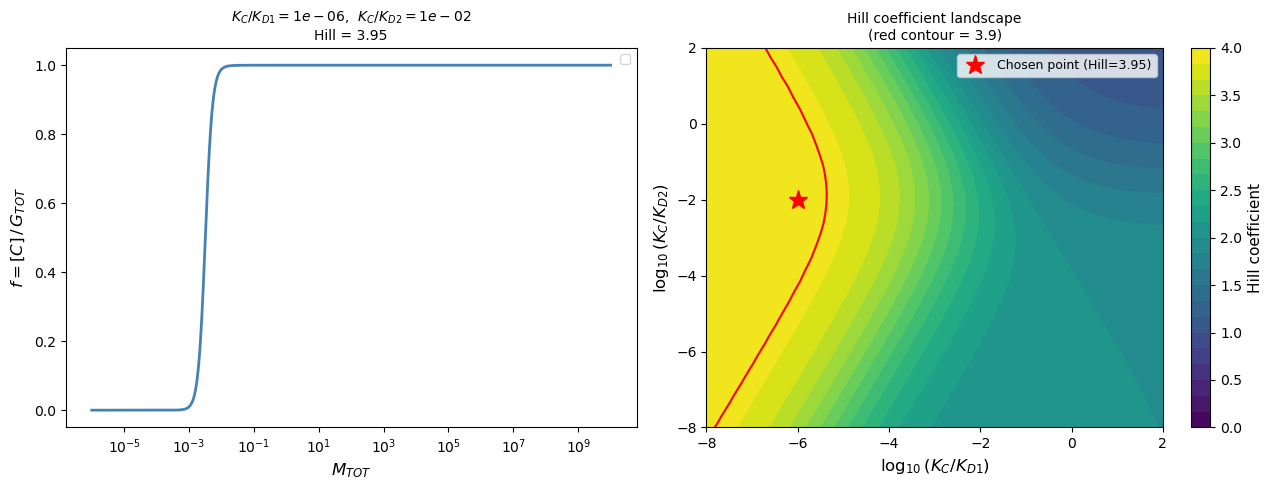

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def solve_output(Mtot_array, KD1, KD2, KC):
    """For each Mtot, solve Eq.1 for [T] via Brent's method, then compute f from Eq.2."""
    outputs = np.zeros(len(Mtot_array))
    for i, Mtot in enumerate(Mtot_array):
        def residual(T):
            M = (T * KD1**2 * KD2)**0.25
            D = (T * KD2 / KD1)**0.5
            return M + 2*D + 4*T - Mtot
        try:
            T_sol = brentq(residual, 1e-30, Mtot * 100, xtol=1e-14)
        except ValueError:
            T_sol = 0.0
        outputs[i] = (T_sol / KC) / (1 + T_sol / KC)
    return outputs


def hill_coefficient(Mtot_array, outputs):
    """Estimate Hill coefficient from interpolated 10%/90% signal values."""
    if outputs.max() < 0.9 or outputs.min() > 0.1:
        return np.nan
    try:
        f_interp = interp1d(outputs, Mtot_array)
        M10 = f_interp(0.1)
        M90 = f_interp(0.9)
        return np.log(81) / np.log(M90 / M10)
    except Exception:
        return np.nan
    
# --- Chosen parameter conditions that yield Hill >= 3.9 ---
KD1 = 1.0
KC_over_KD1 = 1e-6
KC_over_KD2 = 1e-2

KC  = KC_over_KD1 * KD1
KD2 = KC / KC_over_KD2

Mtot_array = np.logspace(-6, 10, 2000)
outputs = solve_output(Mtot_array, KD1, KD2, KC)
H = hill_coefficient(Mtot_array, outputs)

# --- Sweep to build Hill coefficient heatmap ---
ratio_vals = np.logspace(-8, 2, 40)   # values of KC/KD1 and KC/KD2
Hill_grid  = np.full((len(ratio_vals), len(ratio_vals)), np.nan)

for i, r1 in enumerate(ratio_vals):
    for j, r2 in enumerate(ratio_vals):
        KC_  = r1 * KD1
        KD2_ = KC_ / r2
        out  = solve_output(Mtot_array, KD1, KD2_, KC_)
        Hill_grid[i, j] = hill_coefficient(Mtot_array, out)

print(f"Sweep complete. Max Hill = {np.nanmax(Hill_grid):.3f}")

log_r = np.log10(ratio_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: dose-response curve ---
ax = axes[0]
ax.semilogx(Mtot_array, outputs, color='steelblue', lw=2)
f_interp = interp1d(outputs, Mtot_array)
ax.set_xlabel(r'$M_{TOT}$', fontsize=12)
ax.set_ylabel(r'$f = [C]\,/\,G_{TOT}$', fontsize=12)
ax.set_title(
    fr'$K_C/K_{{D1}}={KC_over_KD1:.0e}$,  $K_C/K_{{D2}}={KC_over_KD2:.0e}$'
    f'\nHill = {H:.2f}',
    fontsize=10
)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)

# --- Right: heatmap ---
ax2 = axes[1]
cf = ax2.contourf(log_r, log_r, Hill_grid.T,
                  levels=np.linspace(0, 4, 25), cmap='viridis')
ax2.contour(log_r, log_r, Hill_grid.T,
            levels=[3.9], colors='red', linewidths=1.5)
ax2.plot(np.log10(KC_over_KD1), np.log10(KC_over_KD2),
         'r*', ms=14, label=f'Chosen point (Hill={H:.2f})')
cbar = plt.colorbar(cf, ax=ax2)
cbar.set_label('Hill coefficient', fontsize=11)
ax2.set_xlabel(r'$\log_{10}(K_C / K_{D1})$', fontsize=12)
ax2.set_ylabel(r'$\log_{10}(K_C / K_{D2})$', fontsize=12)
ax2.set_title('Hill coefficient landscape\n(red contour = 3.9)', fontsize=10)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


When $K_C \ll K_{D1}$ and $K_C \ll K_{D2}$, monomers get funneled through two sequential assembly steps before any output forms. Since $[T] \propto [M]^4$, small changes in $M_{TOT}$ cause huge changes in tetramer concentration, driving a switch-like response with Hill $\approx 4$.

# Location of Jupyter Notebook

This file was created in jupyter notebook, rendered into `.html` through `jupyter nbconvert --to html PS9/PS9.ipynb` then the `.html` file was saved as a `.pdf`. The location of all said files are [github.com/caterer-z-t/CHEN_5150/PS9](https://github.com/caterer-z-t/CHEN_5150/tree/main/PS9)

Please contact [ztcaterer@colorado.edu](mailto:ztcaterer@colorado.edu) if there are any issues or concerns. 

Thanks :-)

### Disclosure
Generative artificial intelligence tools were used to assist with this project. All generated content was reviewed, edited, and verified by the authors, who take full responsibility for the accuracy, integrity, and final content of this work. 